# Lab 1 — Inherently Interpretable Models
### M.Tech Course: Explainable & Interpretable Machine Learning

**Lab Title:** Inherently Interpretable Models

**Duration:** 3 hours

---

## 1. Introduction

Machine learning models are broadly classified into two categories based on how easily
a human can understand *why* they make a particular prediction:

| Category | Description | Examples |
|---|---|---|
| **Black-box models** | Predictions are accurate, but the internal decision logic is too complex for a human to follow directly. Explanations require *post-hoc* tools (LIME, SHAP, etc.). | Random Forests, Gradient Boosting, Deep Neural Networks |
| **Inherently (intrinsically) interpretable models** | The model's structure *itself* is simple enough that a human can read off the reasoning — no separate explanation technique is needed. | Linear/Logistic Regression, Decision Trees, Decision Rules, k-NN, Naive Bayes, Generalized Additive Models (GAMs) |

This lab focuses on the **second** category. We will train several inherently
interpretable models on a real dataset, and for each one we will explicitly answer:

1. **What does the model look like internally?** (its parameters / structure)
2. **How do we read that structure as an explanation?**
3. **What are the interpretability properties** (simulatability, decomposability, sparsity) it satisfies?
4. **What is the accuracy–interpretability trade-off** compared to the others?

### Properties used to judge interpretability (Lipton, 2016)
- **Simulatability** — Can a human mentally "run" the model on an input in a reasonable amount of time?
- **Decomposability** — Can each part of the model (a coefficient, a tree node, a rule) be given an intuitive explanation on its own?
- **Algorithmic transparency** — Do we understand *how* the training procedure arrives at the model?

---

## 2. Learning Objectives

By the end of this lab, students will be able to:

1. Train and interpret a **Logistic Regression** model using coefficients and odds ratios.
2. Train and interpret a **Decision Tree** by reading tree paths as IF–THEN rules.
3. Extract an explicit **rule list** from a tree and evaluate its size/complexity.
4. Interpret a **k-Nearest Neighbors** model using case-based (example-based) reasoning.
5. Interpret a **Naive Bayes** model via per-feature log-likelihood contributions.
6. Train a **Generalized Additive Model (GAM)** and read its per-feature shape functions.
7. Quantitatively compare **accuracy vs. interpretability** across all models.


## 3. Environment Setup

We use only well-known Python libraries: `numpy`, `pandas`, `matplotlib`, `seaborn`,
`scikit-learn`, and `pygam` (for the Generalized Additive Model experiment).

> If `pygam` is not installed in your environment, run:
> ```
> pip install pygam
> ```


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from pygam import LogisticGAM, s

sns.set_style("whitegrid")
np.random.seed(42)
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 4. Dataset: Breast Cancer Wisconsin (Diagnostic)

We use the **Breast Cancer Wisconsin** dataset built into scikit-learn. It is a good
choice for an *interpretability* lab because:

- It is a **binary classification** task (malignant vs. benign) — easy to reason about.
- Its 30 features (e.g., `mean radius`, `mean texture`, `worst concavity`) have **real,
  human-understandable clinical meaning**, so coefficients and rules can be interpreted
  in domain terms rather than abstract numbers.
- It is small enough to visualize trees and rules without clutter.

For readability in this lab, we will work with a **reduced subset of 6 features**.


In [37]:
data = load_breast_cancer()
X_full = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")  # 0 = malignant, 1 = benign

# Pick 6 clinically-intuitive features to keep the models easy to read
selected_features = [
    "mean radius", "mean texture", "mean perimeter",
    "mean smoothness", "mean concavity", "worst area"
]
X = X_full[selected_features]

print("Dataset shape:", X.shape)
print("Class balance:\n", y.value_counts().rename({0: "malignant", 1: "benign"}))
X.head()


Dataset shape: (569, 6)
Class balance:
 target
benign       357
malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean smoothness,mean concavity,worst area
0,17.99,10.38,122.80,0.11840,0.3001,2019.0
1,20.57,17.77,132.90,0.08474,0.0869,1956.0
2,19.69,21.25,130.00,0.10960,0.1974,1709.0
3,11.42,20.38,77.58,0.14250,0.2414,567.7
4,20.29,14.34,135.10,0.10030,0.1980,1575.0


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=2024, stratify=y
)

# Standardize features -- important for reading logistic-regression coefficients
# on a comparable scale, and for k-NN distance calculations.
scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_s  = pd.DataFrame(scaler.transform(X_test),  columns=X.columns, index=X_test.index)

print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])


Train size: 426  Test size: 143


## 5. Experiment 1 — Logistic Regression

**Why it is inherently interpretable:** The model computes a single linear combination
of the (standardized) features, then squashes it through a sigmoid:

$$P(\text{benign}) = \sigma(\beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p)$$

Each coefficient $\beta_i$ tells us, on its own (decomposability), how that feature
pushes the prediction toward "benign" or "malignant" — holding the other features fixed.
Exponentiating a coefficient, $e^{\beta_i}$, gives the **odds ratio**: how much the odds
of "benign" multiply for a one-standard-deviation increase in that feature.


In [39]:
logreg = LogisticRegression(max_iter=5000)
logreg.fit(X_train_s, y_train)

y_pred_lr = logreg.predict(X_test_s)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Test Accuracy: {acc_lr:.4f}\n")

coef_table = pd.DataFrame({
    "feature": X.columns,
    "coefficient": logreg.coef_[0],
    "odds_ratio": np.exp(logreg.coef_[0])
}).sort_values("coefficient", key=np.abs, ascending=False)

print(coef_table.to_string(index=False))


Logistic Regression Test Accuracy: 0.9580

        feature  coefficient  odds_ratio
     worst area    -3.112182    0.044504
mean smoothness    -1.333968    0.263430
   mean texture    -1.233367    0.291310
 mean concavity    -1.222887    0.294379
    mean radius    -1.035819    0.354936
 mean perimeter    -0.921228    0.398030


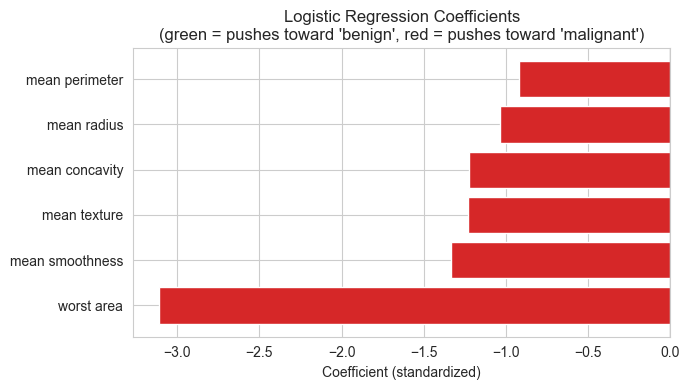

In [40]:
plt.figure(figsize=(7, 4))
colors = ["#d62728" if c < 0 else "#2ca02c" for c in coef_table["coefficient"]]
plt.barh(coef_table["feature"], coef_table["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coefficient (standardized)")
plt.title("Logistic Regression Coefficients\n(green = pushes toward 'benign', red = pushes toward 'malignant')")
plt.tight_layout()
plt.show()


**How to read this (worked example):**
Suppose `worst area` has coefficient $\beta = -2.1$. Since features are standardized,
this means: *for every one-standard-deviation increase in `worst area` (holding other
features fixed), the log-odds of the tumor being benign drop by 2.1*, i.e. the odds of
malignancy increase by a factor of $e^{2.1} \approx 8.2$. This is a **fully simulatable**
explanation — a student can compute it by hand for any patient.


## 6. Experiment 2 — Decision Tree

**Why it is inherently interpretable:** A shallow decision tree can be read top-to-bottom
as a sequence of IF–THEN questions. Each **root-to-leaf path** is, by itself, a complete,
human-readable explanation for that prediction (decomposability + simulatability).

We deliberately restrict `max_depth=3` — deeper trees become accurate but lose
interpretability (too many paths for a human to hold in memory at once).


In [41]:
tree = DecisionTreeClassifier(max_depth=3, random_state=2024)
tree.fit(X_train, y_train)  # trees don't need scaled features

y_pred_tree = tree.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_tree)
print(f"Decision Tree (depth=3) Test Accuracy: {acc_tree:.4f}")
print(f"Number of leaves (= number of distinct explanation rules): {tree.get_n_leaves()}")


Decision Tree (depth=3) Test Accuracy: 0.9441
Number of leaves (= number of distinct explanation rules): 8


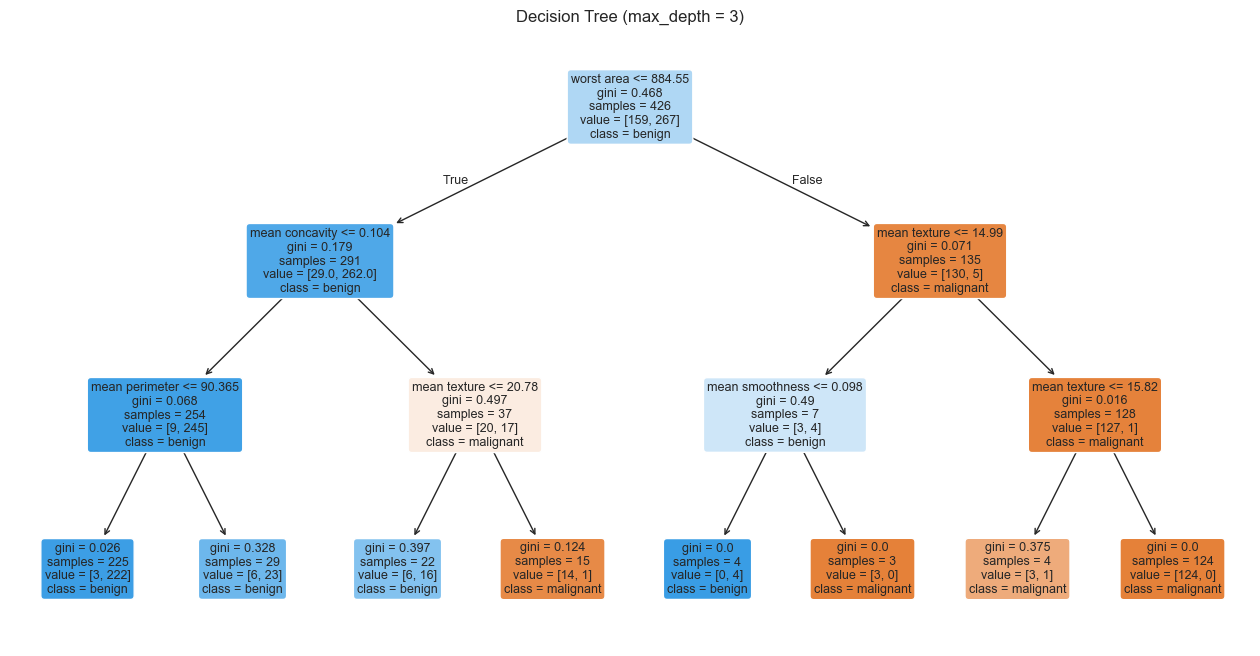

In [42]:
plt.figure(figsize=(16, 8))
plot_tree(tree, feature_names=X.columns, class_names=["malignant", "benign"],
          filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree (max_depth = 3)")
plt.show()


In [43]:
rules_text = export_text(tree, feature_names=list(X.columns))
print(rules_text)


|--- worst area <= 884.55
|   |--- mean concavity <= 0.10
|   |   |--- mean perimeter <= 90.37
|   |   |   |--- class: 1
|   |   |--- mean perimeter >  90.37
|   |   |   |--- class: 1
|   |--- mean concavity >  0.10
|   |   |--- mean texture <= 20.78
|   |   |   |--- class: 1
|   |   |--- mean texture >  20.78
|   |   |   |--- class: 0
|--- worst area >  884.55
|   |--- mean texture <= 14.99
|   |   |--- mean smoothness <= 0.10
|   |   |   |--- class: 1
|   |   |--- mean smoothness >  0.10
|   |   |   |--- class: 0
|   |--- mean texture >  14.99
|   |   |--- mean texture <= 15.82
|   |   |   |--- class: 0
|   |   |--- mean texture >  15.82
|   |   |   |--- class: 0



**How to read this:** Each branch of the printed tree is literally an IF–THEN rule,
e.g. *"IF `worst area` <= 880.4 AND `mean concavity` <= 0.09 THEN predict benign."*
A clinician could apply this rule with a ruler and a calculator — no black box involved.


## 7. Experiment 3 — Explicit Rule List (Rule Extraction)

Beyond reading the tree diagram, we can **programmatically extract every root-to-leaf
path as an explicit IF–THEN rule string**. This is useful when we want to hand the
explanation to a non-technical stakeholder as a checklist, or count how many total
rules the model uses (a measure of model complexity / interpretability cost).


In [44]:
def extract_rules(tree_model, feature_names, class_names):
    tree_ = tree_model.tree_
    feature_name = [
        feature_names[i] if i != -2 else "undefined!"
        for i in tree_.feature
    ]
    rules = []

    def recurse(node, conditions):
        if tree_.feature[node] != -2:  # not a leaf
            name = feature_name[node]
            threshold = tree_.threshold[node]
            recurse(tree_.children_left[node], conditions + [f"({name} <= {threshold:.2f})"])
            recurse(tree_.children_right[node], conditions + [f"({name} > {threshold:.2f})"])
        else:
            counts = tree_.value[node][0]
            predicted_class = class_names[int(np.argmax(counts))]
            confidence = counts.max() / counts.sum()
            rule = "IF " + " AND ".join(conditions) if conditions else "TRUE"
            rules.append(f"{rule}  =>  predict '{predicted_class}'  (confidence={confidence:.2f}, n={int(counts.sum())})")

    recurse(0, [])
    return rules

rule_list = extract_rules(tree, list(X.columns), ["malignant", "benign"])
for i, r in enumerate(rule_list, 1):
    print(f"Rule {i}: {r}")

print(f"\nTotal number of rules extracted: {len(rule_list)}")


Rule 1: IF (worst area <= 884.55) AND (mean concavity <= 0.10) AND (mean perimeter <= 90.37)  =>  predict 'benign'  (confidence=0.99, n=1)
Rule 2: IF (worst area <= 884.55) AND (mean concavity <= 0.10) AND (mean perimeter > 90.37)  =>  predict 'benign'  (confidence=0.79, n=1)
Rule 3: IF (worst area <= 884.55) AND (mean concavity > 0.10) AND (mean texture <= 20.78)  =>  predict 'benign'  (confidence=0.73, n=1)
Rule 4: IF (worst area <= 884.55) AND (mean concavity > 0.10) AND (mean texture > 20.78)  =>  predict 'malignant'  (confidence=0.93, n=1)
Rule 5: IF (worst area > 884.55) AND (mean texture <= 14.99) AND (mean smoothness <= 0.10)  =>  predict 'benign'  (confidence=1.00, n=1)
Rule 6: IF (worst area > 884.55) AND (mean texture <= 14.99) AND (mean smoothness > 0.10)  =>  predict 'malignant'  (confidence=1.00, n=1)
Rule 7: IF (worst area > 884.55) AND (mean texture > 14.99) AND (mean texture <= 15.82)  =>  predict 'malignant'  (confidence=0.75, n=1)
Rule 8: IF (worst area > 884.55) AND

**Interpretability metric:** the **number of rules** and the **average number of
conditions per rule** are common, simple complexity measures for rule-based models.
Fewer, shorter rules are considered more interpretable (higher simulatability).


## 8. Experiment 4 — k-Nearest Neighbors (Case-Based / Example-Based Interpretability)

**Why it is inherently interpretable:** k-NN makes no explicit "model" at all — it
predicts a new point's label by looking at the $k$ most similar *training examples* and
taking a majority vote. The explanation for any prediction is simply: **"here are the
$k$ patients most similar to this one, and this is how they were diagnosed."** This is
called **case-based** or **example-based** interpretability — it mirrors how doctors
often reason ("this looks like Patient X, who turned out benign").


In [45]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train)

y_pred_knn = knn.predict(X_test_s)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"k-NN (k=5) Test Accuracy: {acc_knn:.4f}")


k-NN (k=5) Test Accuracy: 0.9301


In [46]:
# Explain ONE specific test-set prediction using its nearest neighbors
sample_idx = 0
sample = X_test_s.iloc[[sample_idx]]
true_label = y_test.iloc[sample_idx]
pred_label = knn.predict(sample)[0]

distances, neighbor_idx = knn.kneighbors(sample, n_neighbors=5)
neighbor_labels = y_train.iloc[neighbor_idx[0]].values

print(f"Test patient #{sample_idx}: true label = {true_label}, predicted = {pred_label}")
print(f"Labels of its 5 nearest training neighbors: {neighbor_labels}")
print("Explanation: the prediction is the majority vote among these 5 most similar patients.")

neighbor_table = X_train.iloc[neighbor_idx[0]].copy()
neighbor_table["distance"] = distances[0]
neighbor_table["label"] = neighbor_labels
neighbor_table


Test patient #0: true label = 0, predicted = 0
Labels of its 5 nearest training neighbors: [0 0 0 0 0]
Explanation: the prediction is the majority vote among these 5 most similar patients.


,mean radius,mean texture,mean perimeter,mean smoothness,mean concavity,worst area,distance,label
121,18.66,17.12,121.4,0.10540,0.1457,1549.0,0.329224,0
85,18.46,18.52,121.1,0.09874,0.1335,1603.0,0.348145,0
282,19.40,18.18,127.2,0.10370,0.1626,1628.0,0.455153,0
516,18.31,20.58,120.8,0.10680,0.1569,1493.0,0.842287,0
517,19.89,20.26,130.5,0.10370,0.1411,1646.0,0.864797,0


## 9. Experiment 5 — Gaussian Naive Bayes

**Why it is inherently interpretable:** Naive Bayes assumes features are conditionally
independent given the class, so the prediction decomposes into a **sum of independent,
per-feature log-likelihood contributions**:

$$\log P(y \mid x) \;\propto\; \log P(y) + \sum_{i=1}^{p} \log P(x_i \mid y)$$

Each term $\log P(x_i \mid y)$ can be inspected on its own — exactly the *decomposability*
property we want.


In [47]:
nb = GaussianNB()
nb.fit(X_train_s, y_train)

y_pred_nb = nb.predict(X_test_s)
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"Gaussian Naive Bayes Test Accuracy: {acc_nb:.4f}")

# Show the learned per-class, per-feature Gaussian parameters (mean, variance)
nb_params = pd.DataFrame(nb.theta_, columns=X.columns, index=["malignant", "benign"])
print("\nLearned per-class feature means (standardized units):")
print(nb_params.to_string())


Gaussian Naive Bayes Test Accuracy: 0.9301

Learned per-class feature means (standardized units):
           mean radius  mean texture  mean perimeter  mean smoothness  mean concavity  worst area
malignant     0.945517      0.542024        0.961403         0.493953        0.884484    0.938017
benign       -0.563061     -0.322778       -0.572521        -0.294152       -0.526715   -0.558595


**How to read this:** for a given feature, compare its mean under the "malignant"
row vs. the "benign" row. A test patient whose feature value sits much closer to the
"malignant" mean than the "benign" mean contributes positive evidence for malignancy —
and this contribution can be computed and shown to a user feature-by-feature.


## 10. Experiment 6 — Generalized Additive Model (GAM)

**Why it is inherently interpretable:** A GAM generalizes linear/logistic regression by
allowing each feature to have its own **smooth, non-linear shape function** $f_i$, while
still keeping the features additively separate (no interactions):

$$\text{logit}(P(y=1\mid x)) = \beta_0 + f_1(x_1) + f_2(x_2) + \dots + f_p(x_p)$$

Because the effect of each feature is still isolated in its own $f_i$, we can **plot**
$f_i$ against $x_i$ and read off the exact (possibly non-linear) relationship — something
plain logistic regression cannot capture, but which is still fully decomposable and
visually simulatable.


In [48]:
gam = LogisticGAM(
    s(0) + s(1) + s(2) + s(3) + s(4) + s(5)
).fit(X_train_s.values, y_train.values)

y_pred_gam = (gam.predict_mu(X_test_s.values) > 0.5).astype(int)
acc_gam = accuracy_score(y_test, y_pred_gam)
print(f"GAM Test Accuracy: {acc_gam:.4f}")


GAM Test Accuracy: 0.9860


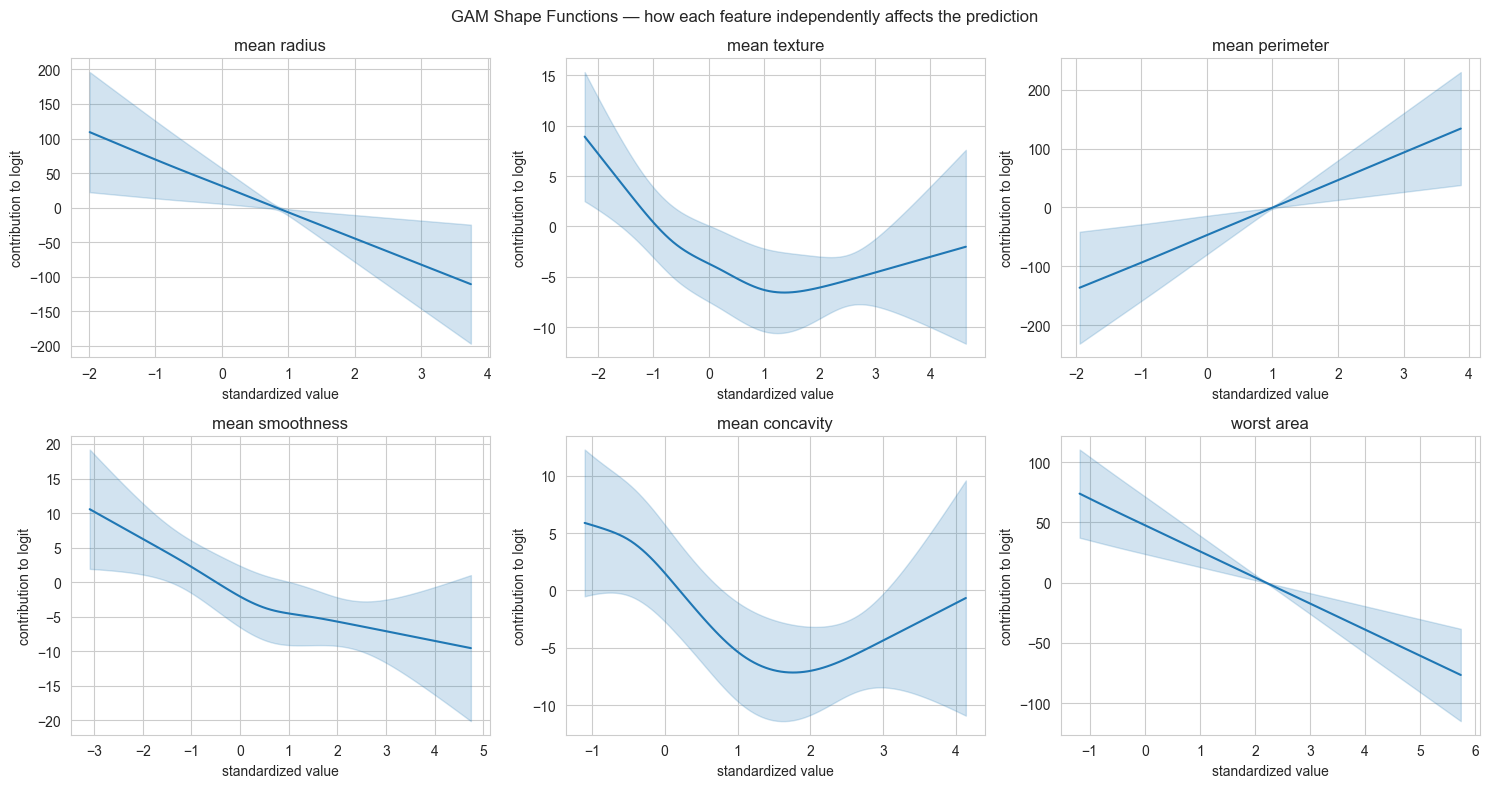

In [49]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, feature in enumerate(X.columns):
    XX = gam.generate_X_grid(term=i)
    pdep, confi = gam.partial_dependence(term=i, X=XX, width=0.95)
    axes[i].plot(XX[:, i], pdep, color="#1f77b4")
    axes[i].fill_between(XX[:, i], confi[:, 0], confi[:, 1], alpha=0.2, color="#1f77b4")
    axes[i].set_title(feature)
    axes[i].set_xlabel("standardized value")
    axes[i].set_ylabel("contribution to logit")

plt.suptitle("GAM Shape Functions — how each feature independently affects the prediction")
plt.tight_layout()
plt.show()


**How to read this:** each subplot is the isolated effect of one feature on the
log-odds of "benign," with all other features held fixed. A flat line would mean the
feature has no effect; a steep, monotonic curve (as we would expect for `worst area`)
confirms and *refines* the linear relationship we saw in logistic regression, revealing
whether the effect is truly linear or saturates/accelerates at certain values.


## 11. Comparative Analysis: Accuracy vs. Interpretability

We now bring all five models together and compare them along two axes:

1. **Predictive accuracy** on the held-out test set.
2. **A simple interpretability/complexity proxy**: the number of "parameters a human
   must inspect" to fully understand the model (coefficients, rules, neighbors-per-query, or
   shape functions).


In [50]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression", "Decision Tree (depth=3)",
        "k-NN (k=5)", "Gaussian Naive Bayes", "GAM"
    ],
    "Test Accuracy": [acc_lr, acc_tree, acc_knn, acc_nb, acc_gam],
    "Interpretability unit": [
        "coefficient", "rule (leaf)", "neighbor set per query", "per-feature likelihood", "shape function"
    ],
    "Number of units to inspect": [
        len(X.columns), tree.get_n_leaves(), 5, len(X.columns), len(X.columns)
    ],
    "Simulatable by hand?": ["Yes", "Yes", "Yes (local)", "Yes", "Yes (needs a plot)"]
})

results = results.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
results


,Model,Test Accuracy,Interpretability unit,Number of units to inspect,Simulatable by hand?
0,GAM,0.986014,shape function,6,Yes (needs a plot)
1,Logistic Regression,0.958042,coefficient,6,Yes
2,Decision Tree (depth=3),0.944056,rule (leaf),8,Yes
3,k-NN (k=5),0.930070,neighbor set per query,5,Yes (local)
4,Gaussian Naive Bayes,0.930070,per-feature likelihood,6,Yes


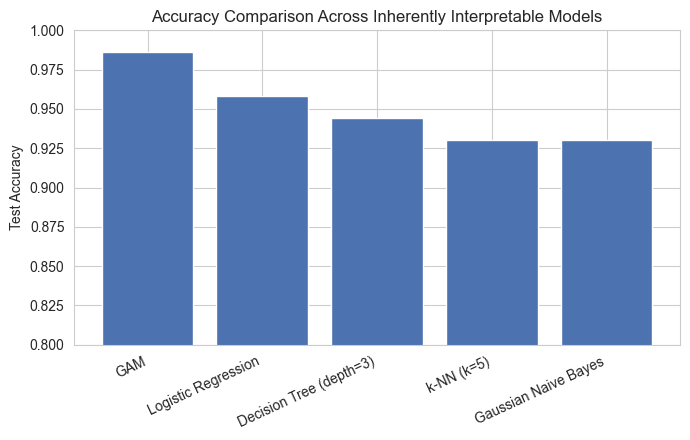

In [51]:
plt.figure(figsize=(7, 4.5))
plt.bar(results["Model"], results["Test Accuracy"], color="#4c72b0")
plt.ylim(0.8, 1.0)
plt.ylabel("Test Accuracy")
plt.title("Accuracy Comparison Across Inherently Interpretable Models")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


### Discussion

- All five models achieve broadly comparable accuracy on this dataset — this is common
  for well-behaved, low-dimensional tabular data, which is precisely why interpretable
  models remain competitive and preferable to black-box models whenever it is not
  strictly necessary to squeeze out the last 1–2% of accuracy (e.g., in medicine, credit
  scoring, criminal justice).
- **Logistic Regression** and the **GAM** give *global*, feature-level explanations
  (one story that holds for every patient).
- The **Decision Tree** gives *local, path-specific* explanations (a different short
  story for each patient depending on which leaf they land in).
- **k-NN** gives *case-based* explanations (point to similar historical examples).
- **Naive Bayes** gives *probabilistic, additive* explanations.
- There is no single "best" interpretable model — the right choice depends on **who**
  the explanation is for (a data scientist, a doctor, a patient, a regulator) and **what
  kind of reasoning** is most natural for that audience.


## 12. Lab Exercises (To Be Submitted)

1. Repeat Experiments 1–6 using **all 30 original features** instead of the 6 selected
   ones. How does interpretability degrade as the number of features grows? Propose one
   way to keep the model interpretable even with 30 features.
2. Vary the decision tree's `max_depth` from 1 to 8 and plot **test accuracy** vs.
   **number of leaves**. At what depth do you judge the tree "no longer interpretable,"
   and why?
3. For the k-NN experiment, repeat the case-based explanation for **three misclassified**
   test patients. What do their nearest neighbors suggest went wrong?
4. Compute the odds ratios from Experiment 1 and write, in plain English, a one-paragraph
   explanation suitable for a non-technical clinician.
5. Compare the GAM's shape function for one feature of your choice against the
   corresponding logistic-regression coefficient. Does the GAM support or contradict the
   assumption of linearity? Justify using the plot.
6. **(Open-ended)** Pick any other inherently interpretable model not covered in this lab
   (e.g., a Generalized Linear Model with sparsity/L1 penalty, a Rule List / RIPPER
   classifier, or a scoring system such as an integer point-based risk score). Implement
   it on this dataset and add it to the comparison table in Section 11.

---
### References
1. Z. C. Lipton, "The Mythos of Model Interpretability," *ACM Queue*, 2018.
2. C. Molnar, *Interpretable Machine Learning*, 2022 (freely available online).
3. T. Hastie, R. Tibshirani, *Generalized Additive Models*, Statistical Science, 1986.


## Exercise 1 — Repeat Experiments 1–6 Using All 30 Features ( Lab Submissions )

The original experiments used 6 selected features for readability. In this exercise,
all 30 original features from the Breast Cancer Wisconsin dataset are used.

The same train/test split and random state are retained so that the results remain
comparable with the original experiments.

In [52]:
# ============================================================
# EXERCISE 1: ALL 30 ORIGINAL FEATURES
# ============================================================

# Use all 30 original features
X_thirty = X_full.copy()

# Same train/test split as the original experiments
X_thirty_train, X_thirty_test, y_thirty_train, y_thirty_test = train_test_split(
    X_thirty,
    y,
    test_size=0.25,
    random_state=2024,
    stratify=y
)

# Standardization for Logistic Regression, k-NN and GAM
scaler30 = StandardScaler()

X_thirty_train_s = pd.DataFrame(
    scaler30.fit_transform(X_thirty_train),
    columns=X_thirty.columns,
    index=X_thirty_train.index
)

X_thirty_test_s = pd.DataFrame(
    scaler30.transform(X_thirty_test),
    columns=X_thirty.columns,
    index=X_thirty_test.index
)

print("All-feature dataset shape:", X_thirty.shape)
print("Training samples:", X_thirty_train.shape[0])
print("Testing samples:", X_thirty_test.shape[0])
print("Number of features:", X_thirty.shape[1])

All-feature dataset shape: (569, 30)
Training samples: 426
Testing samples: 143
Number of features: 30


In [53]:
# ============================================================
# EXPERIMENT 1 WITH ALL 30 FEATURES: LOGISTIC REGRESSION
# ============================================================

lr_model30 = LogisticRegression(max_iter=5000)
lr_model30.fit(X_thirty_train_s, y_thirty_train)

y_pred_lr30 = lr_model30.predict(X_thirty_test_s)

acc_lr_30 = accuracy_score(y_thirty_test, y_pred_lr30)

coef_table30 = pd.DataFrame({
    "feature": X_thirty.columns,
    "coefficient": lr_model30.coef_[0],
    "odds_ratio": np.exp(lr_model30.coef_[0])
}).sort_values(
    "coefficient",
    key=np.abs,
    ascending=False
)

print(f"Logistic Regression (30 features) Test Accuracy: {acc_lr_30:.4f}")
print("\nTop 15 coefficients by absolute magnitude:")
print(coef_table30.head(15).to_string(index=False))

Logistic Regression (30 features) Test Accuracy: 0.9720

Top 15 coefficients by absolute magnitude:
                feature  coefficient  odds_ratio
           radius error    -1.245839    0.287699
       worst smoothness    -1.091448    0.335730
    mean concave points    -1.016949    0.361697
             area error    -0.916523    0.399907
         worst symmetry    -0.890606    0.410407
      compactness error     0.851238    2.342544
           worst radius    -0.838474    0.432370
          worst texture    -0.821908    0.439592
         mean concavity    -0.819368    0.440710
        worst concavity    -0.813938    0.443110
   worst concave points    -0.795745    0.451245
             worst area    -0.749698    0.472509
fractal dimension error     0.748754    2.114365
        perimeter error    -0.744250    0.475091
        worst perimeter    -0.687765    0.502698


Decision Tree (depth=3, 30 features) Test Accuracy: 0.9510
Number of leaves: 7


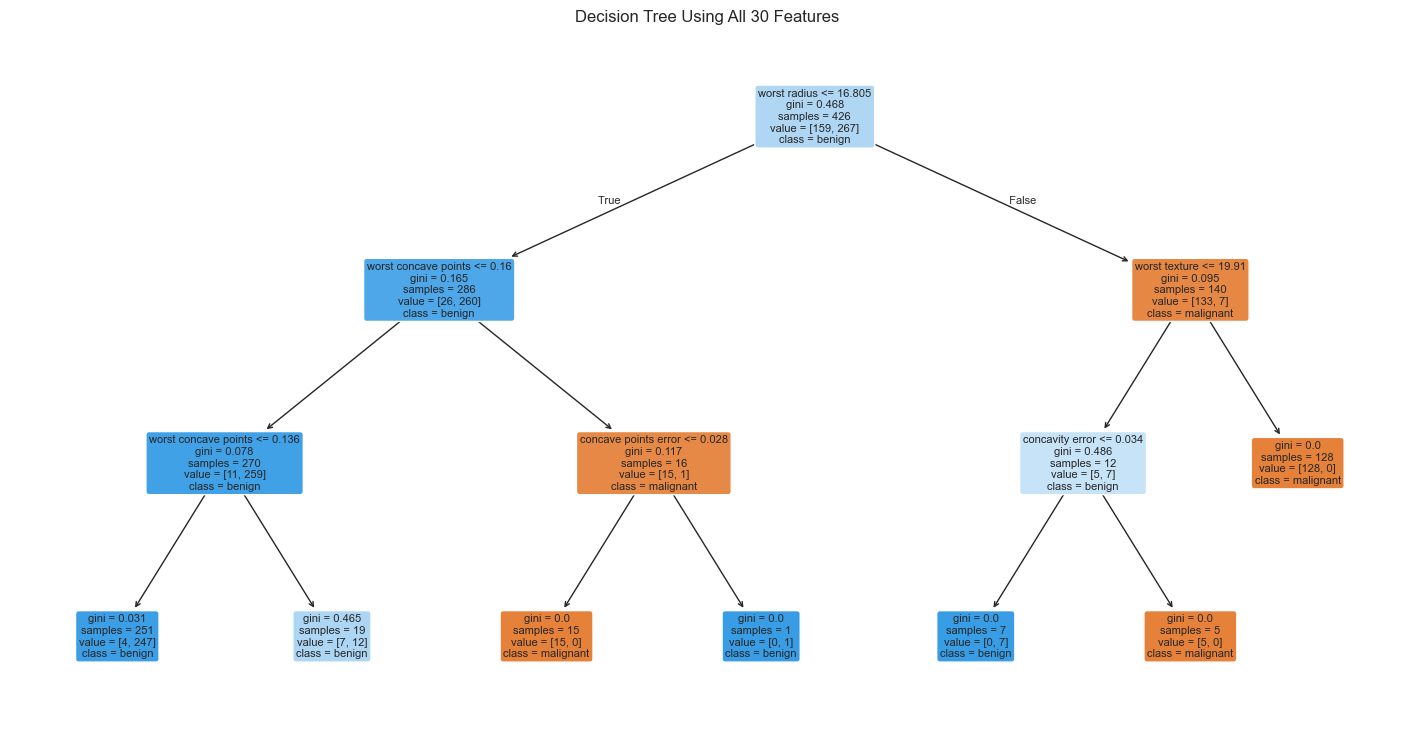

In [54]:
# ============================================================
# EXPERIMENT 2 WITH ALL 30 FEATURES: DECISION TREE
# ============================================================

dt_model30 = DecisionTreeClassifier(
    max_depth=3,
    random_state=2024
)

dt_model30.fit(X_thirty_train, y_thirty_train)

y_pred_dt_model30 = dt_model30.predict(X_thirty_test)

acc_dt_model30 = accuracy_score(y_thirty_test, y_pred_dt_model30)

print(f"Decision Tree (depth=3, 30 features) Test Accuracy: {acc_dt_model30:.4f}")
print(f"Number of leaves: {dt_model30.get_n_leaves()}")

plt.figure(figsize=(18, 9))

plot_tree(
    dt_model30,
    feature_names=X_thirty.columns,
    class_names=["malignant", "benign"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Using All 30 Features")
plt.show()

In [55]:
# ============================================================
# EXPERIMENT 3 WITH ALL 30 FEATURES: RULE EXTRACTION
# ============================================================

rules30 = extract_rules(
    dt_model30,
    list(X_thirty.columns),
    ["malignant", "benign"]
)

print("Extracted rules using all 30 features:\n")

for i, rule in enumerate(rules30, start=1):
    print(f"Rule {i}: {rule}")

num_rules30 = len(rules30)

avg_conditions30 = np.mean([
    rule.count("AND") + 1
    for rule in rules30
])

print("\nNumber of rules:", num_rules30)
print(f"Average conditions per rule: {avg_conditions30:.2f}")

Extracted rules using all 30 features:

Rule 1: IF (worst radius <= 16.81) AND (worst concave points <= 0.16) AND (worst concave points <= 0.14)  =>  predict 'benign'  (confidence=0.98, n=1)
Rule 2: IF (worst radius <= 16.81) AND (worst concave points <= 0.16) AND (worst concave points > 0.14)  =>  predict 'benign'  (confidence=0.63, n=1)
Rule 3: IF (worst radius <= 16.81) AND (worst concave points > 0.16) AND (concave points error <= 0.03)  =>  predict 'malignant'  (confidence=1.00, n=1)
Rule 4: IF (worst radius <= 16.81) AND (worst concave points > 0.16) AND (concave points error > 0.03)  =>  predict 'benign'  (confidence=1.00, n=1)
Rule 5: IF (worst radius > 16.81) AND (worst texture <= 19.91) AND (concavity error <= 0.03)  =>  predict 'benign'  (confidence=1.00, n=1)
Rule 6: IF (worst radius > 16.81) AND (worst texture <= 19.91) AND (concavity error > 0.03)  =>  predict 'malignant'  (confidence=1.00, n=1)
Rule 7: IF (worst radius > 16.81) AND (worst texture > 19.91)  =>  predict 'm

In [56]:
# ============================================================
# EXPERIMENT 4 WITH ALL 30 FEATURES: k-NN
# ============================================================

knn_model30 = KNeighborsClassifier(n_neighbors=5)

knn_model30.fit(X_thirty_train_s, y_thirty_train)

y_pred_knn_model30 = knn_model30.predict(X_thirty_test_s)

acc_knn_model30 = accuracy_score(y_thirty_test, y_pred_knn_model30)

print(f"k-NN (k=5, 30 features) Test Accuracy: {acc_knn_model30:.4f}")

# Explain one test prediction using its nearest neighbors
sample_idx30 = 0

sample30 = X_thirty_test_s.iloc[[sample_idx30]]

true_label30 = y_thirty_test.iloc[sample_idx30]
pred_label30 = knn_model30.predict(sample30)[0]

distances30, neighbor_idx30 = knn_model30.kneighbors(
    sample30,
    n_neighbors=5
)

neighbor_labels30 = y_thirty_train.iloc[neighbor_idx30[0]].values

print(f"\nTest patient #{sample_idx30}")
print("True label:", true_label30)
print("Predicted label:", pred_label30)
print("Labels of 5 nearest training neighbors:", neighbor_labels30)
print("Distances:", distances30[0])

k-NN (k=5, 30 features) Test Accuracy: 0.9510

Test patient #0
True label: 0
Predicted label: 0
Labels of 5 nearest training neighbors: [0 0 0 0 0]
Distances: [2.01861024 2.53779917 2.64791347 2.7098729  2.88524642]


In [57]:
# ============================================================
# EXPERIMENT 5 WITH ALL 30 FEATURES: GAUSSIAN NAIVE BAYES
# ============================================================

nb_model30 = GaussianNB()

nb_model30.fit(X_thirty_train_s, y_thirty_train)

y_pred_nb_model30 = nb_model30.predict(X_thirty_test_s)

acc_nb_model30 = accuracy_score(y_thirty_test, y_pred_nb_model30)

print(f"Gaussian Naive Bayes (30 features) Test Accuracy: {acc_nb_model30:.4f}")

nb_params30 = pd.DataFrame(
    nb_model30.theta_,
    columns=X_thirty.columns,
    index=["malignant", "benign"]
)

print("\nLearned class means for the 30 features:")
display(nb_params30)

Gaussian Naive Bayes (30 features) Test Accuracy: 0.9301

Learned class means for the 30 features:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
malignant,0.945517,0.542024,0.961403,0.918219,0.493953,0.776625,0.884484,1.009665,0.469713,0.000007,...,1.000415,0.598215,1.009048,0.938017,0.566054,0.745612,0.820628,1.019437,0.562412,0.380629
benign,-0.563061,-0.322778,-0.572521,-0.546805,-0.294152,-0.462485,-0.526715,-0.601261,-0.279716,-0.000004,...,-0.595753,-0.356241,-0.600894,-0.558595,-0.337088,-0.444016,-0.488689,-0.607080,-0.334920,-0.226666


In [58]:
# ============================================================
# EXPERIMENT 6 WITH ALL 30 FEATURES: GAM
# ============================================================

# Build the GAM terms without using Python's sum() starting from 0.
# Start with the first smooth term and then add the remaining terms.

gam_terms30 = s(0)

for i in range(1, X_thirty.shape[1]):
    gam_terms30 = gam_terms30 + s(i)

print("Number of GAM smooth terms:", X_thirty.shape[1])

gam_model30 = LogisticGAM(
    gam_terms30
).fit(
    X_thirty_train_s.values,
    y_thirty_train.values
)

y_pred_gam_model30 = (
    gam_model30.predict_mu(X_thirty_test_s.values) > 0.5
).astype(int)

acc_gam_model30 = accuracy_score(
    y_thirty_test,
    y_pred_gam_model30
)

print(f"GAM (30 features) Test Accuracy: {acc_gam_model30:.4f}")

Number of GAM smooth terms: 30
did not converge
GAM (30 features) Test Accuracy: 0.9650


,Model,Test Accuracy,Interpretability Unit,Number of Units to Inspect
0,Logistic Regression,0.972028,coefficient,30
1,GAM,0.965035,shape function,30
2,Decision Tree (depth=3),0.951049,rule (leaf),7
3,k-NN (k=5),0.951049,neighbor set per query,5
4,Gaussian Naive Bayes,0.930070,per-feature likelihood,30


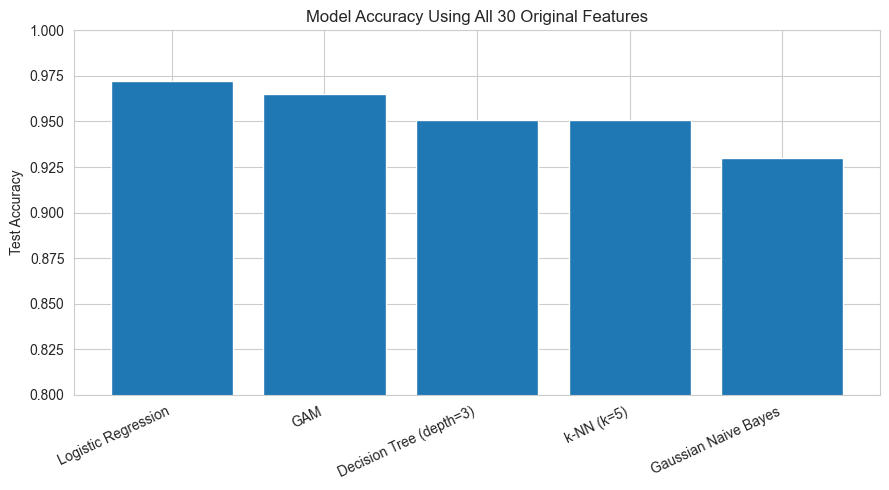

In [59]:
# ============================================================
# ALL 30 FEATURES: MODEL COMPARISON
# ============================================================

results30 = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree (depth=3)",
        "k-NN (k=5)",
        "Gaussian Naive Bayes",
        "GAM"
    ],
    "Test Accuracy": [
        acc_lr_30,
        acc_dt_model30,
        acc_knn_model30,
        acc_nb_model30,
        acc_gam_model30
    ],
    "Interpretability Unit": [
        "coefficient",
        "rule (leaf)",
        "neighbor set per query",
        "per-feature likelihood",
        "shape function"
    ],
    "Number of Units to Inspect": [
        30,
        dt_model30.get_n_leaves(),
        5,
        30,
        30
    ]
})

results30 = results30.sort_values(
    "Test Accuracy",
    ascending=False
).reset_index(drop=True)

display(results30)

plt.figure(figsize=(9, 5))

plt.bar(
    results30["Model"],
    results30["Test Accuracy"]
)

plt.ylim(0.8, 1.0)
plt.ylabel("Test Accuracy")
plt.title("Model Accuracy Using All 30 Original Features")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

In [60]:
# ============================================================
# INTERPRETABILITY: 6 FEATURES VS 30 FEATURES
# ============================================================

interpretability_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "k-NN",
        "Gaussian Naive Bayes",
        "GAM"
    ],
    "6 Features": [
        len(X.columns),
        tree.get_n_leaves(),
        5,
        len(X.columns),
        len(X.columns)
    ],
    "30 Features": [
        30,
        dt_model30.get_n_leaves(),
        5,
        30,
        30
    ]
})

display(interpretability_comparison)

print("\nInterpretability observation:")
print(
    "Increasing from 6 to 30 features increases the number of feature-level "
    "quantities that must be considered for Logistic Regression, Naive Bayes, "
    "and GAM. Although k-NN still uses five neighbors for each prediction, "
    "each neighbor is described in a higher-dimensional feature space. "
    "The shallow Decision Tree remains relatively compact because its number "
    "of leaves is controlled by max_depth."
)

,Model,6 Features,30 Features
0,Logistic Regression,6,30
1,Decision Tree,8,7
2,k-NN,5,5
3,Gaussian Naive Bayes,6,30
4,GAM,6,30



Interpretability observation:
Increasing from 6 to 30 features increases the number of feature-level quantities that must be considered for Logistic Regression, Naive Bayes, and GAM. Although k-NN still uses five neighbors for each prediction, each neighbor is described in a higher-dimensional feature space. The shallow Decision Tree remains relatively compact because its number of leaves is controlled by max_depth.


### Exercise 1 — Interpretation

When we use all 30 features, the sheer volume of information for a human to review increases significantly.
For Logistic Regression, Naive Bayes, and GAM, the number of feature-level quantities
increases from 6 to 30, making the global explanation more difficult to inspect and
remember. For k-NN, the explanation still consists of the five nearest examples, but
each example is now represented in a 30-dimensional feature space, making similarity
harder to reason about directly. A shallow Decision Tree can remain relatively
interpretable because its depth and number of leaves can be explicitly constrained.

One way to preserve interpretability with 30 features is to use **feature selection or
sparsity**. For example, an L1-regularized logistic regression model can automatically
drive less useful coefficients toward zero, leaving only a smaller set of features in
the final explanation.

## Exercise 2 — Decision Tree Complexity

The decision tree depth is varied from 1 through 8. For each depth,
test accuracy and the number of leaves are recorded.

In [61]:
# ============================================================
# EXERCISE 2: DECISION TREE DEPTH 1 TO 8
# ============================================================

tree_depth_results = []

for depth in range(1, 9):

    tree_d = DecisionTreeClassifier(
        max_depth=depth,
        random_state=2024
    )

    tree_d.fit(X_train, y_train)

    pred_d = tree_d.predict(X_test)

    accuracy_d = accuracy_score(
        y_test,
        pred_d
    )

    leaves_d = tree_d.get_n_leaves()

    tree_depth_results.append({
        "max_depth": depth,
        "test_accuracy": accuracy_d,
        "number_of_leaves": leaves_d
    })

tree_depth_results = pd.DataFrame(
    tree_depth_results
)

display(tree_depth_results)

,max_depth,test_accuracy,number_of_leaves
0,1,0.923077,2
1,2,0.930070,4
2,3,0.944056,8
3,4,0.923077,13
4,5,0.923077,19
5,6,0.923077,21
6,7,0.937063,23
7,8,0.930070,25


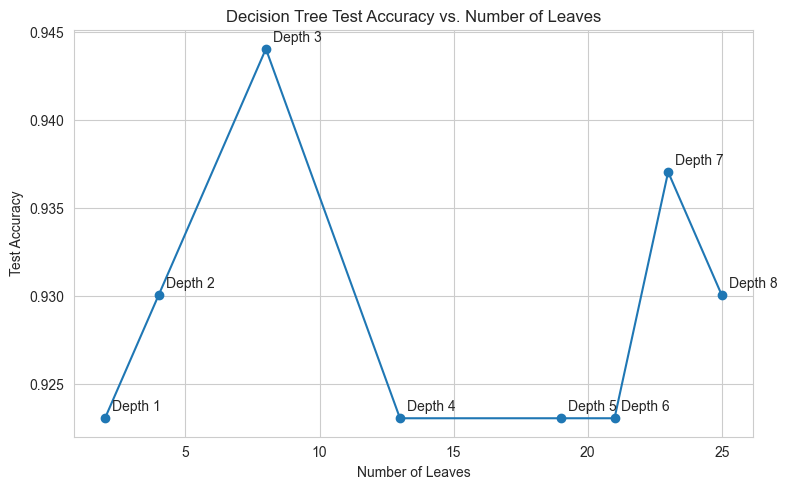

In [62]:
# ============================================================
# TEST ACCURACY VS NUMBER OF LEAVES
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    tree_depth_results["number_of_leaves"],
    tree_depth_results["test_accuracy"],
    marker="o"
)

for _, row in tree_depth_results.iterrows():
    plt.annotate(
        f"Depth {int(row['max_depth'])}",
        (
            row["number_of_leaves"],
            row["test_accuracy"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Number of Leaves")
plt.ylabel("Test Accuracy")
plt.title("Decision Tree Test Accuracy vs. Number of Leaves")
plt.grid(True)
plt.tight_layout()
plt.show()

In [63]:
# ============================================================
# BEST ACCURACY AND COMPLEXITY SUMMARY
# ============================================================

best_tree_row = tree_depth_results.loc[
    tree_depth_results["test_accuracy"].idxmax()
]

print(
    f"Highest test accuracy occurs at depth "
    f"{int(best_tree_row['max_depth'])} "
    f"with {int(best_tree_row['number_of_leaves'])} leaves."
)

print(
    f"Test accuracy = {best_tree_row['test_accuracy']:.4f}"
)

print(
    "\nInterpretability criterion:"
)

print(
    "As depth and number of leaves increase, the number of "
    "IF-THEN paths a human must inspect also increases. "
    "Therefore, a deeper tree may become difficult to simulate "
    "manually even when its predictive accuracy improves."
)

Highest test accuracy occurs at depth 3 with 8 leaves.
Test accuracy = 0.9441

Interpretability criterion:
As depth and number of leaves increase, the number of IF-THEN paths a human must inspect also increases. Therefore, a deeper tree may become difficult to simulate manually even when its predictive accuracy improves.


### Exercise 2 — Interpretation

As a decision tree grows deeper and adds more leaves, its interpretability drops
because a user must follow increasingly long decision paths and remember more possible
IF–THEN rules. In this experiment, the depth-3 tree used in the original laboratory is
a reasonable compromise because its paths remain short enough to inspect manually.

For this dataset, I would regard the point at which the tree begins producing many
branches and substantially more leaves than the shallow tree as the point where
interpretability starts to deteriorate. The exact choice should be justified using the
accuracy-versus-leaf-count plot above rather than accuracy alone.

## Exercise 3 — Case-Based Explanations for Three Misclassified Patients

In [64]:
# ============================================================
# EXERCISE 3: THREE MISCLASSIFIED k-NN PATIENTS
# ============================================================

# Find all misclassified test observations
misclassified_indices = np.where(
    y_pred_knn != y_test.values
)[0]

print(
    f"Number of misclassified test patients: "
    f"{len(misclassified_indices)}"
)

# Select the first three misclassified cases
selected_misclassified = misclassified_indices[:3]

if len(selected_misclassified) < 3:
    print(
        "Fewer than three misclassified patients were found "
        "with the current experiment settings."
    )
else:

    for case_number, test_position in enumerate(
        selected_misclassified,
        start=1
    ):

        sample = X_test_s.iloc[[test_position]]

        true_label = y_test.iloc[test_position]
        predicted_label = y_pred_knn[test_position]

        distances, neighbor_indices = knn.kneighbors(
            sample,
            n_neighbors=5
        )

        neighbor_labels = y_train.iloc[
            neighbor_indices[0]
        ].values

        neighbor_original_indices = y_train.iloc[
            neighbor_indices[0]
        ].index

        print("=" * 70)
        print(f"MISCLASSIFIED PATIENT {case_number}")
        print("=" * 70)

        print(f"Test-set position: {test_position}")
        print(f"Original dataset index: {X_test.index[test_position]}")
        print(f"True label: {true_label}")
        print(f"Predicted label: {predicted_label}")

        print("\nNearest-neighbor information:")

        neighbor_table = pd.DataFrame({
            "training_index": neighbor_original_indices,
            "distance": distances[0],
            "neighbor_label": neighbor_labels
        })

        display(neighbor_table)

        print(
            "\nNeighbor label counts:",
            pd.Series(neighbor_labels).value_counts().to_dict()
        )

        print(
            "\nInterpretation: The k-NN prediction is based on the "
            "majority label among the five most similar training "
            "patients. Because this patient was misclassified, "
            "the local neighborhood contains enough examples of "
            "the predicted class to outweigh the true class."
        )

Number of misclassified test patients: 10
MISCLASSIFIED PATIENT 1
Test-set position: 48
Original dataset index: 157
True label: 1
Predicted label: 0

Nearest-neighbor information:


,training_index,distance,neighbor_label
0,489,0.278010,0
1,119,0.920506,0
2,207,1.029668,0
3,147,1.050084,1
4,197,1.093376,0



Neighbor label counts: {0: 4, 1: 1}

Interpretation: The k-NN prediction is based on the majority label among the five most similar training patients. Because this patient was misclassified, the local neighborhood contains enough examples of the predicted class to outweigh the true class.
MISCLASSIFIED PATIENT 2
Test-set position: 64
Original dataset index: 81
True label: 1
Predicted label: 0

Nearest-neighbor information:


,training_index,distance,neighbor_label
0,215,0.593671,0
1,356,0.694056,1
2,89,0.767726,1
3,73,0.797571,0
4,146,0.823822,0



Neighbor label counts: {0: 3, 1: 2}

Interpretation: The k-NN prediction is based on the majority label among the five most similar training patients. Because this patient was misclassified, the local neighborhood contains enough examples of the predicted class to outweigh the true class.
MISCLASSIFIED PATIENT 3
Test-set position: 68
Original dataset index: 31
True label: 0
Predicted label: 1

Nearest-neighbor information:


,training_index,distance,neighbor_label
0,356,0.769870,1
1,512,0.802522,0
2,469,0.821605,1
3,506,0.874841,1
4,146,0.899579,0



Neighbor label counts: {1: 3, 0: 2}

Interpretation: The k-NN prediction is based on the majority label among the five most similar training patients. Because this patient was misclassified, the local neighborhood contains enough examples of the predicted class to outweigh the true class.


### Exercise 3 — Interpretation

For each misclassified patient, the nearest-neighbor table shows the five training
examples used to support the prediction. A misclassification occurs when the majority
class among these similar historical examples differs from the patient's true class.

This highlights the pros and cons of example-based interpretation:
the prediction can be explained directly using real neighboring examples, but an
ambiguous local neighborhood can cause the model to choose the wrong class.

###  Exercise 4 — Clinician-Friendly Odds Ratio Explanation

The exercise asks specifically for a plain-English, non-technical clinician explanation based on the Logistic Regression odds ratios.

In [65]:
# ============================================================
# EXERCISE 4: ODDS RATIOS FOR CLINICIAN EXPLANATION
# ============================================================

# Sort by the strongest odds-ratio effect
clinician_table = coef_table.copy()

clinician_table["effect_strength"] = np.abs(
    np.log(clinician_table["odds_ratio"])
)

clinician_table = clinician_table.sort_values(
    "effect_strength",
    ascending=False
)

display(
    clinician_table[
        ["feature", "coefficient", "odds_ratio"]
    ]
)

# Select the strongest feature
top_feature = clinician_table.iloc[0]

feature_name = top_feature["feature"]
coefficient = top_feature["coefficient"]
odds_ratio = top_feature["odds_ratio"]

if coefficient < 0:
    interpretation = (
        f"A one-standard-deviation increase in {feature_name} "
        f"is associated with the odds of a benign classification "
        f"being multiplied by approximately {odds_ratio:.3f}. "
        f"Because this value is below 1, the model therefore "
        f"moves the prediction toward malignancy."
    )
else:
    interpretation = (
        f"A one-standard-deviation increase in {feature_name} "
        f"is associated with the odds of a benign classification "
        f"being multiplied by approximately {odds_ratio:.3f}. "
        f"Because this value is above 1, the model therefore "
        f"moves the prediction toward a benign classification."
    )

print("\nCLINICIAN-FRIENDLY EXPLANATION:\n")

print(
    "The logistic regression model estimates the probability "
    "that a tumor is benign using six measured characteristics. "
    "Each characteristic contributes independently to the model's "
    "decision. The strongest effect in this model is associated "
    f"with {feature_name}. {interpretation} "
    "These odds ratios describe the model's association with the "
    "classification; they should not be interpreted as proving "
    "that changing a clinical measurement would itself cause the "
    "diagnosis to change."
)

,feature,coefficient,odds_ratio
5,worst area,-3.112182,0.044504
3,mean smoothness,-1.333968,0.263430
1,mean texture,-1.233367,0.291310
4,mean concavity,-1.222887,0.294379
0,mean radius,-1.035819,0.354936
2,mean perimeter,-0.921228,0.398030



CLINICIAN-FRIENDLY EXPLANATION:

The logistic regression model estimates the probability that a tumor is benign using six measured characteristics. Each characteristic contributes independently to the model's decision. The strongest effect in this model is associated with worst area. A one-standard-deviation increase in worst area is associated with the odds of a benign classification being multiplied by approximately 0.045. Because this value is below 1, the model therefore moves the prediction toward malignancy. These odds ratios describe the model's association with the classification; they should not be interpreted as proving that changing a clinical measurement would itself cause the diagnosis to change.


### Exercise 4 — Clinician-Friendly Explanation

The logistic regression model estimates whether a tumor is likely to be benign or
malignant using the six selected measurements. Each measurement contributes separately
to the final prediction. The odds ratio tells us how the model's odds of a benign
classification change when a feature increases by one standard deviation, while the
other features are held constant. An odds ratio below 1 moves the model toward a
malignant classification, whereas an odds ratio above 1 moves it toward a benign
classification. These are model-based associations and should not be interpreted as
causal clinical effects.

## Exercise 5 — GAM Shape Function vs. Logistic Regression

The feature selected for comparison is **worst area**.

The logistic regression model assumes a linear relationship between the standardized
feature and the log-odds of the prediction. The GAM relaxes this assumption by learning
a smooth shape function for the same feature.

Feature: worst area
Logistic Regression coefficient: -3.1122


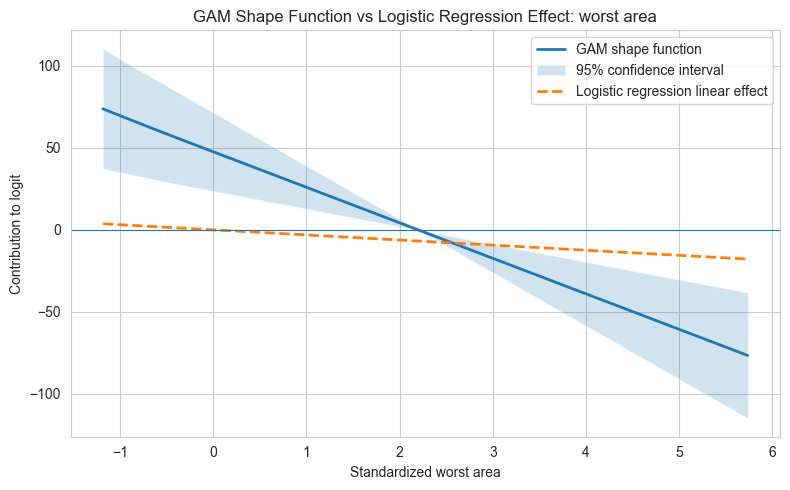

In [66]:
# ============================================================
# EXERCISE 5: GAM VS LOGISTIC REGRESSION
# Feature: worst area
# ============================================================

comparison_feature = "worst area"
feature_index = list(X.columns).index(comparison_feature)

# Logistic regression coefficient
lr_coefficient = logreg.coef_[0][feature_index]

print(f"Feature: {comparison_feature}")
print(f"Logistic Regression coefficient: {lr_coefficient:.4f}")

# Generate GAM grid for the selected feature
XX = gam.generate_X_grid(term=feature_index)

pdep, confi = gam.partial_dependence(
    term=feature_index,
    X=XX,
    width=0.95
)

plt.figure(figsize=(8, 5))

plt.plot(
    XX[:, feature_index],
    pdep,
    linewidth=2,
    label="GAM shape function"
)

plt.fill_between(
    XX[:, feature_index],
    confi[:, 0],
    confi[:, 1],
    alpha=0.2,
    label="95% confidence interval"
)

# Linear relationship implied by logistic regression
linear_component = (
    lr_coefficient *
    XX[:, feature_index]
)

plt.plot(
    XX[:, feature_index],
    linear_component,
    linestyle="--",
    linewidth=2,
    label="Logistic regression linear effect"
)

plt.axhline(
    0,
    linewidth=0.8
)

plt.xlabel("Standardized worst area")
plt.ylabel("Contribution to logit")
plt.title(
    "GAM Shape Function vs Logistic Regression Effect: worst area"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [67]:
# ============================================================
# QUANTITATIVE CHECK OF GAM LINEARITY
# ============================================================

# Fit a straight line to the GAM partial dependence values
linear_fit = np.polyfit(
    XX[:, feature_index],
    pdep,
    deg=1
)

linear_pred = np.polyval(
    linear_fit,
    XX[:, feature_index]
)

# R^2 between GAM shape and its best straight-line approximation
ss_res = np.sum(
    (pdep - linear_pred) ** 2
)

ss_tot = np.sum(
    (pdep - np.mean(pdep)) ** 2
)

gam_linearity_r2 = 1 - (ss_res / ss_tot)

print(
    f"R² of the best straight-line approximation to the GAM "
    f"shape function: {gam_linearity_r2:.4f}"
)

if gam_linearity_r2 >= 0.95:
    conclusion = (
        "The GAM shape is approximately linear over the observed "
        "range, so the GAM largely supports the linearity assumption."
    )
else:
    conclusion = (
        "The GAM shape departs noticeably from a straight line, "
        "suggesting that the linearity assumption is not fully adequate."
    )

print("\nConclusion:")
print(conclusion)

R² of the best straight-line approximation to the GAM shape function: 1.0000

Conclusion:
The GAM shape is approximately linear over the observed range, so the GAM largely supports the linearity assumption.


### Exercise 5 — Interpretation

The logistic regression model represents the effect of `worst area` using one constant
coefficient, which corresponds to a straight-line relationship between the standardized
feature and the log-odds.

The GAM does not require this effect to be linear. Its shape function shows how the
contribution changes across different values of `worst area`. The comparison plot and
the straight-line fit provide evidence for whether the linearity assumption is
reasonable. If the GAM curve closely follows a straight line, the logistic regression
assumption is supported. If the curve bends, flattens, or changes slope substantially,
the GAM reveals non-linearity that logistic regression cannot represent.

## Exercise 6 — Additional Interpretable Model: Sparse L1 Logistic Regression

An L1-regularized Logistic Regression model is added as an additional inherently
interpretable model.

The L1 penalty encourages some feature coefficients to become exactly zero,
producing a sparse model that can be easier to inspect than a model using all
available features.

In [68]:
# ============================================================
# EXERCISE 6: L1-REGULARIZED LOGISTIC REGRESSION
# ============================================================

sparse_logreg = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=1.0,
    max_iter=5000,
    random_state=2024
)

sparse_logreg.fit(
    X_thirty_train_s,
    y_thirty_train
)

y_pred_sparse = sparse_logreg.predict(
    X_thirty_test_s
)

acc_sparse = accuracy_score(
    y_thirty_test,
    y_pred_sparse
)

sparse_coef_table = pd.DataFrame({
    "feature": X_thirty.columns,
    "coefficient": sparse_logreg.coef_[0]
})

sparse_coef_table["odds_ratio"] = np.exp(
    sparse_coef_table["coefficient"]
)

sparse_coef_table["absolute_coefficient"] = np.abs(
    sparse_coef_table["coefficient"]
)

sparse_coef_table = sparse_coef_table.sort_values(
    "absolute_coefficient",
    ascending=False
)

non_zero_features = sparse_coef_table[
    sparse_coef_table["coefficient"] != 0
]

zero_features = sparse_coef_table[
    sparse_coef_table["coefficient"] == 0
]

print(
    f"L1 Logistic Regression Test Accuracy: "
    f"{acc_sparse:.4f}"
)

print(
    f"\nTotal number of features: {len(X_thirty.columns)}"
)

print(
    f"Non-zero coefficients: {len(non_zero_features)}"
)

print(
    f"Zero coefficients: {len(zero_features)}"
)

print("\nNon-zero features used by the sparse model:")
display(
    non_zero_features[
        ["feature", "coefficient", "odds_ratio"]
    ]
)

L1 Logistic Regression Test Accuracy: 0.9580

Total number of features: 30
Non-zero coefficients: 14
Zero coefficients: 16

Non-zero features used by the sparse model:


,feature,coefficient,odds_ratio
20,worst radius,-3.294065,0.037103
10,radius error,-2.590979,0.074947
7,mean concave points,-1.771769,0.170032
21,worst texture,-1.419856,0.241749
26,worst concavity,-1.218500,0.295673
15,compactness error,0.845415,2.328944
24,worst smoothness,-0.818854,0.440937
27,worst concave points,-0.647517,0.523343
28,worst symmetry,-0.567349,0.567027
23,worst area,-0.470687,0.624573


In [69]:
# ============================================================
# ADD L1 MODEL TO THE COMPARISON
# ============================================================

sparse_comparison_row = pd.DataFrame({
    "Model": ["L1-regularized Logistic Regression"],
    "Test Accuracy": [acc_sparse],
    "Interpretability Unit": ["non-zero coefficient"],
    "Number of Units to Inspect": [len(non_zero_features)]
})

# Add the new model to the 30-feature comparison
results_with_sparse = pd.concat(
    [
        results30,
        sparse_comparison_row
    ],
    ignore_index=True
)

results_with_sparse = results_with_sparse.sort_values(
    "Test Accuracy",
    ascending=False
).reset_index(drop=True)

display(results_with_sparse)

,Model,Test Accuracy,Interpretability Unit,Number of Units to Inspect
0,Logistic Regression,0.972028,coefficient,30
1,GAM,0.965035,shape function,30
2,L1-regularized Logistic Regression,0.958042,non-zero coefficient,14
3,Decision Tree (depth=3),0.951049,rule (leaf),7
4,k-NN (k=5),0.951049,neighbor set per query,5
5,Gaussian Naive Bayes,0.930070,per-feature likelihood,30


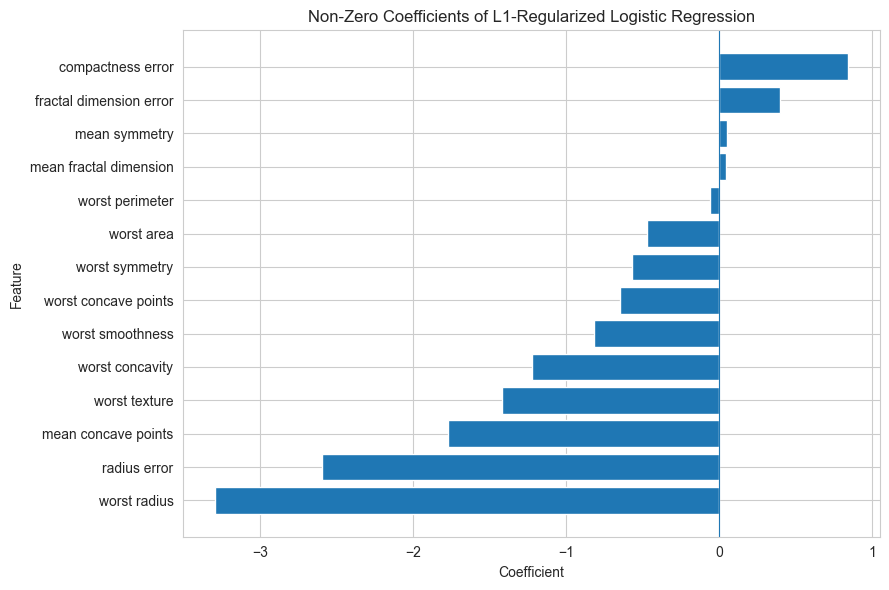

In [70]:
# ============================================================
# VISUALIZE NON-ZERO L1 COEFFICIENTS
# ============================================================

plot_sparse = non_zero_features.sort_values(
    "coefficient"
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_sparse["feature"],
    plot_sparse["coefficient"]
)

plt.axvline(
    0,
    linewidth=0.8
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title(
    "Non-Zero Coefficients of L1-Regularized Logistic Regression"
)

plt.tight_layout()
plt.show()

### Exercise 6 — Interpretation

L1-regularized Logistic Regression remains inherently interpretable because each
prediction is still based on a weighted combination of individual features. Its main
advantage is sparsity: the L1 penalty can set some coefficients exactly to zero.

Therefore, instead of asking a human to inspect all 30 coefficients, only the
non-zero coefficients need to be considered for the model's main decision logic.
This provides a useful compromise between predictive performance and
interpretability.

# Final Summary of Lab Exercises

The additional experiments extend the original six-feature analysis to all 30 features,
investigate decision-tree complexity, provide case-based explanations for three
misclassified k-NN patients, interpret logistic-regression odds ratios in
clinician-friendly language, compare a GAM shape function with the corresponding
logistic-regression effect, and add an L1-regularized sparse logistic-regression model.

Together, these experiments demonstrate that interpretability is not determined only
by predictive accuracy. The number of features, number of rules, explanation length,
and structure of the model all affect how easily a human can understand and simulate
its predictions.